# Stage 4 - Geospatial Analysis

## 03_geospatial.ipynb

#### Produces two choropleth maps that visualise the spatial distribution of crime incidents across South African provinces by:

- Loading the cleaned dataset from `data/processed/sa_crime_clean.csv`,      
- Loading the shapefile from `data/shapefiles/ne_10m_admin_1_states_provinces.shp` and filtering it to South Africa,          
- Verifying province name compatibility between the shapefile and the `sa_crime_clean` dataset,
- Aggregating crime counts by province to produce separate incident totals for all categories across the 12-year period and 2022,    
- Merging aggregated crime data with the GeoDataFrame on province name,     
- Producing a choropleth map visualisation of the total crime by province spanning the full 12-year period,
- Producing a choropleth map visualisation of the total crime by province for 2022, and
- Saving both maps to `reports/figures/` for the dashboarding and technical reporting stages in the project pipeline.

#### Data source: [Crime Statistics of South Africa (2011-2023)](https://www.kaggle.com/datasets/harutyunagababyan/crime-stats-of-south-africa-2011-2023)    
#### Shapefile source: [Natural Earth Admin 1 - States, Provinces (version 5.1.1)](https://www.naturalearthdata.com/downloads/10m-cultural-vectors/10m-admin-1-states-provinces/)

-------------

Imports necessary libraries: `pandas` for data manipulation; `geopandas` for shapefile loading and spatial operations; `pyplot` from `matplotlib` for data visualisation; `warnings` for potential issue alerts; `os` for directory navigation:

In [1]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt               # map rendering
import warnings
import os

Ignores all potential warnings:

In [2]:
warnings.filterwarnings('ignore')

Navigates from notebook's location to project root, i.e. since notebooks live in `notebooks/`, goes up one level to reach project root:

In [3]:
dir_nb = os.getcwd()
project_root = os.path.dirname(dir_nb) 
os.chdir(project_root)                

print(os.getcwd())

C:\Users\Wits-User\Desktop\PROJECTS\sa-crime-statistics


Creates `reports/figures/` directory path if it does not exist:

In [4]:
os.makedirs('reports/figures/', exist_ok = True)

Ensures generated plots are rendered and displayed directly below code:

In [5]:
%matplotlib inline

Sets a consistent visual style for all produced charts:

In [6]:
plt.rcParams.update({
    'font.family'       :  'Arial',
    'figure.dpi'        :  300})   

Loads the Natural Earth Admin 1 shapefile from file, where the global dataset is filtered to South Africa using the `admin` column:

In [7]:
world_gdf = gpd.read_file('data/shapefiles/ne_10m_admin_1_states_provinces.shp')   # creates world shapefile dataframe

sa_gdf = world_gdf[world_gdf['admin'] == 'South Africa'].reset_index()             # filters world dataframe to create South African shapefile dataframe

Before merging the shapefile with the aggregated incident totals, province names must be checked to determine if the names are identical to the `province` entries in `crime_df`:

In [8]:
print(sa_gdf['name'].unique())                          # confirms 9 province names
print(sa_gdf['name'].nunique())                         # expected: 9
print('Coordinate Reference System: ', sa_gdf.crs)      # displays reference system   

<ArrowStringArray>
['Northern Cape', 'KwaZulu-Natal',    'Free State',  'Eastern Cape',
       'Limpopo',    'North West',    'Mpumalanga',  'Western Cape',
       'Gauteng']
Length: 9, dtype: str
9
Coordinate Reference System:  EPSG:4326


Loads the cleaned dataset from file:

In [9]:
crime_df = pd.read_csv('data/processed/sa_crime_clean.csv')

print('Crime statistics dataset read into dataframe!')

Crime statistics dataset read into dataframe!


Verifies dimensions, column labels, and province names of `crime_df` for confirmation purposes:

In [10]:
crime_df.shape

(756, 4)

In [11]:
crime_df.columns.tolist()

['province', 'crime_category', 'financial_year', 'incident_count']

In [12]:
crime_df['province'].unique().tolist()

['Eastern Cape',
 'Free State',
 'Gauteng',
 'KwaZulu-Natal',
 'Limpopo',
 'Mpumalanga',
 'Northern Cape',
 'North West',
 'Western Cape']

Produces the two separate aggregations for the choropleth maps:

In [13]:
# crime total aggregation across all categories and years:
total_df = (crime_df.groupby('province')['incident_count']
            .sum().reset_index())

# crime total aggregation across all categories for 2022 financial year only:
df_2022 = crime_df[crime_df['financial_year'] == 2022]

crime2022_df = (df_2022.groupby('province')['incident_count']
                .sum().reset_index())

print('Crime Total Aggregation For All Years:\n', total_df.sort_values('incident_count', ascending = False))
print('Crime Total Aggregation For 2022:\n', crime2022_df.sort_values('incident_count', ascending = False))

Crime Total Aggregation For All Years:
         province  incident_count
2        Gauteng         7274899
8   Western Cape         5502038
3  KwaZulu-Natal         4153161
0   Eastern Cape         2533731
4        Limpopo         1492403
5     Mpumalanga         1451499
1     Free State         1422327
6     North West         1410042
7  Northern Cape          606367
Crime Total Aggregation For 2022:
         province  incident_count
2        Gauteng          530948
8   Western Cape          397314
3  KwaZulu-Natal          303938
0   Eastern Cape          198141
4        Limpopo          122307
6     North West          115084
1     Free State          110551
5     Mpumalanga          107416
7  Northern Cape           52390


Directly confirms if the province names match in `total_df` and `sa_gdf` prior to merge:

In [14]:
provinces_total_df = sorted(total_df['province'].unique().tolist())
provinces_sa_gdf = sorted(sa_gdf['name'].unique().tolist())

if provinces_total_df == provinces_sa_gdf:
   print('Province names are identical for both total_df and sa_gdf.\n'
         'Proceed with dataframe and shapefile merging.')
else:
   print('Province names do not match.')

Province names are identical for both total_df and sa_gdf.
Proceed with dataframe and shapefile merging.


Merges shapefile with crime totals `total_df` and `crime2022_df`, where `left_on` refers to the shapefile `name` column, and `right_on` refers to the crime dataset `province` column:

In [15]:
sa_map_total = sa_gdf.merge(total_df, 
                            left_on = 'name', 
                            right_on = 'province')

sa_map_2022 = sa_gdf.merge(crime2022_df, 
                           left_on = 'name', 
                           right_on = 'province')

# displays number of province names in newly merged datasets:
print('Number of province names in sa_map_total: ', len(sa_map_total))             # expected: 9
print('Number of province names in sa_map_2022: ', len(sa_map_2022))               # expected: 9

Number of province names in sa_map_total:  9
Number of province names in sa_map_2022:  9


##### Choropleth Map 1 - Total Crime Incidents by Province across 12-year Period

Produces the first labelled choropleth map representing total incident counts per province (represented by variations in colour intensity) across all 12 years and 7 categories:

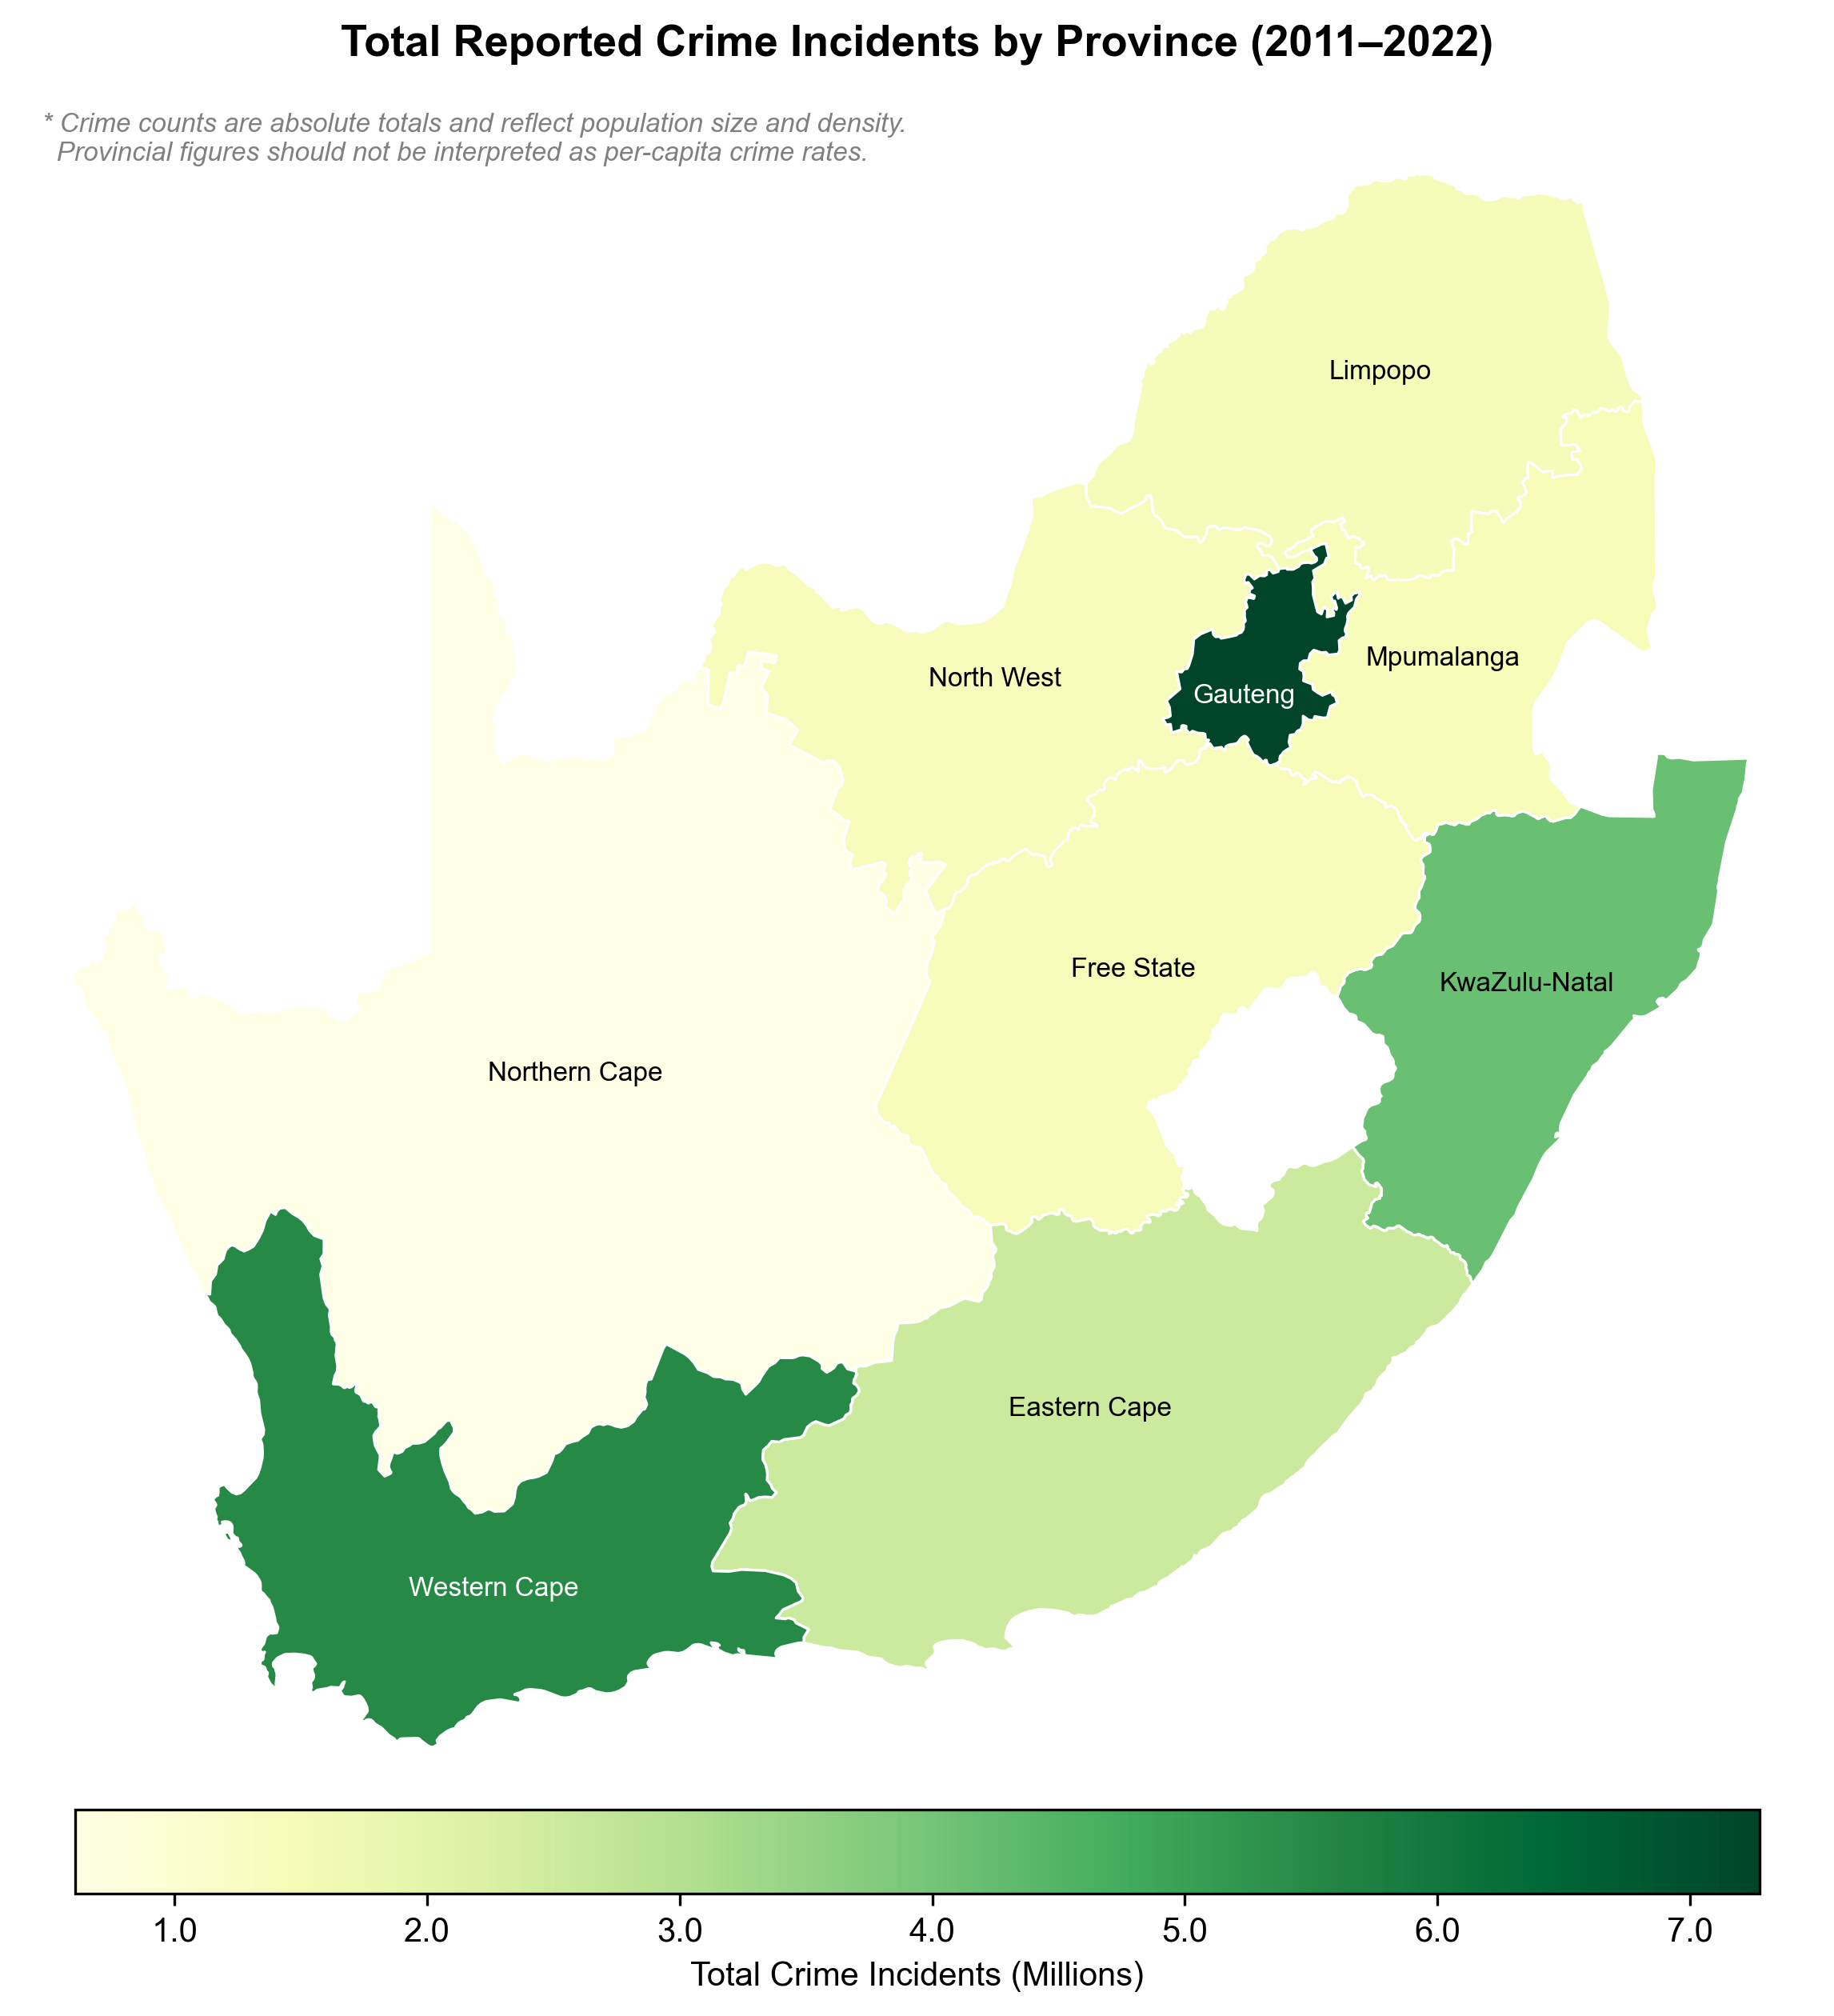

In [16]:
fig1, ax1 = plt.subplots(figsize = (12,9))

sa_map_total.plot(column        = 'incident_count', 
                  cmap          = 'YlGn',                      # uses yellow-green colour map
                  linewidth     =  0.8, 
                  edgecolor     = 'white',
                  legend        = True,
                  legend_kwds   = {'label'      : 'Total Crime Incidents (Millions)',
                                   'orientation': 'horizontal',
                                   'shrink'     : 0.6,
                                   'pad'        : 0.02},
                  ax = ax1)

# province name labels with dynamic colour:
dark_provinces = ['Gauteng', 'Western Cape']

# province name labels that need to be manually shifted to centroid position:
manual_positions = {'Gauteng'      : (27.95, -26.4),          # latitude, longitude
                    'Western Cape' : (20.60, -33.6),
                    'Mpumalanga'   : (29.90, -26.1)} 

# renders province names as centroid labels with special cases:
for _, row in sa_map_total.iterrows():                        # loops through merged sa_gdf rows
    label_colour = 'white' if row['province'] in dark_provinces else 'black'

    # checks whether province has manually specified position:
    if row['province'] in manual_positions:
        cx, cy = manual_positions[row['province']]
    else:
        cx = row.geometry.centroid.x
        cy = row.geometry.centroid.y
    
    ax1.annotate(text      = row['province'],
                xy         = (cx, cy),
                ha         = 'center', 
                fontsize   = 8, 
                color      = label_colour)
                
# chart_formatting:
ax1.set_title('Total Reported Crime Incidents by Province (2011\u20132022)', fontsize = 13, fontweight = 'bold', pad = 12)
ax1.set_axis_off()

# sets limits to clip map to mainland:
ax1.set_xlim([16, 33.5])
ax1.set_ylim([-35, -21.5])

# adds an single text annotation in top left corner of figure:
ax1.text(x         = 0.01,
         y         = 0.99,
         s         = '* Crime counts are absolute totals and reflect population size and density.'
                     '\n  Provincial figures should not be interpreted as per-capita crime rates.',
         transform = ax1.transAxes,
         fontsize  = 8,
         va        = 'top',
         ha        = 'left',
         color     = 'grey',
         style     = 'italic')

# formats colour bar:
colour_bar = ax1.get_figure().axes[-1]
colour_bar.set_xticklabels([f'{x/1e6:.1f}' for x in colour_bar.get_xticks()])           # changes axis formatting to millions annotation
 
plt.tight_layout()                          # ensure better readability
plt.savefig('reports/figures/choropleth_total.png', dpi = 300, bbox_inches = 'tight')
plt.show()

##### Choropleth Map 2 - Total Crime Incidents by Province For 2022 Financial Year:

Produces the second labelled choropleth map representing total incident counts per province (represented by variations in colour intensity) across all 7 categories for 2022 financial year only - adds a time dimension that allows for comparison between historical total and most recent year:

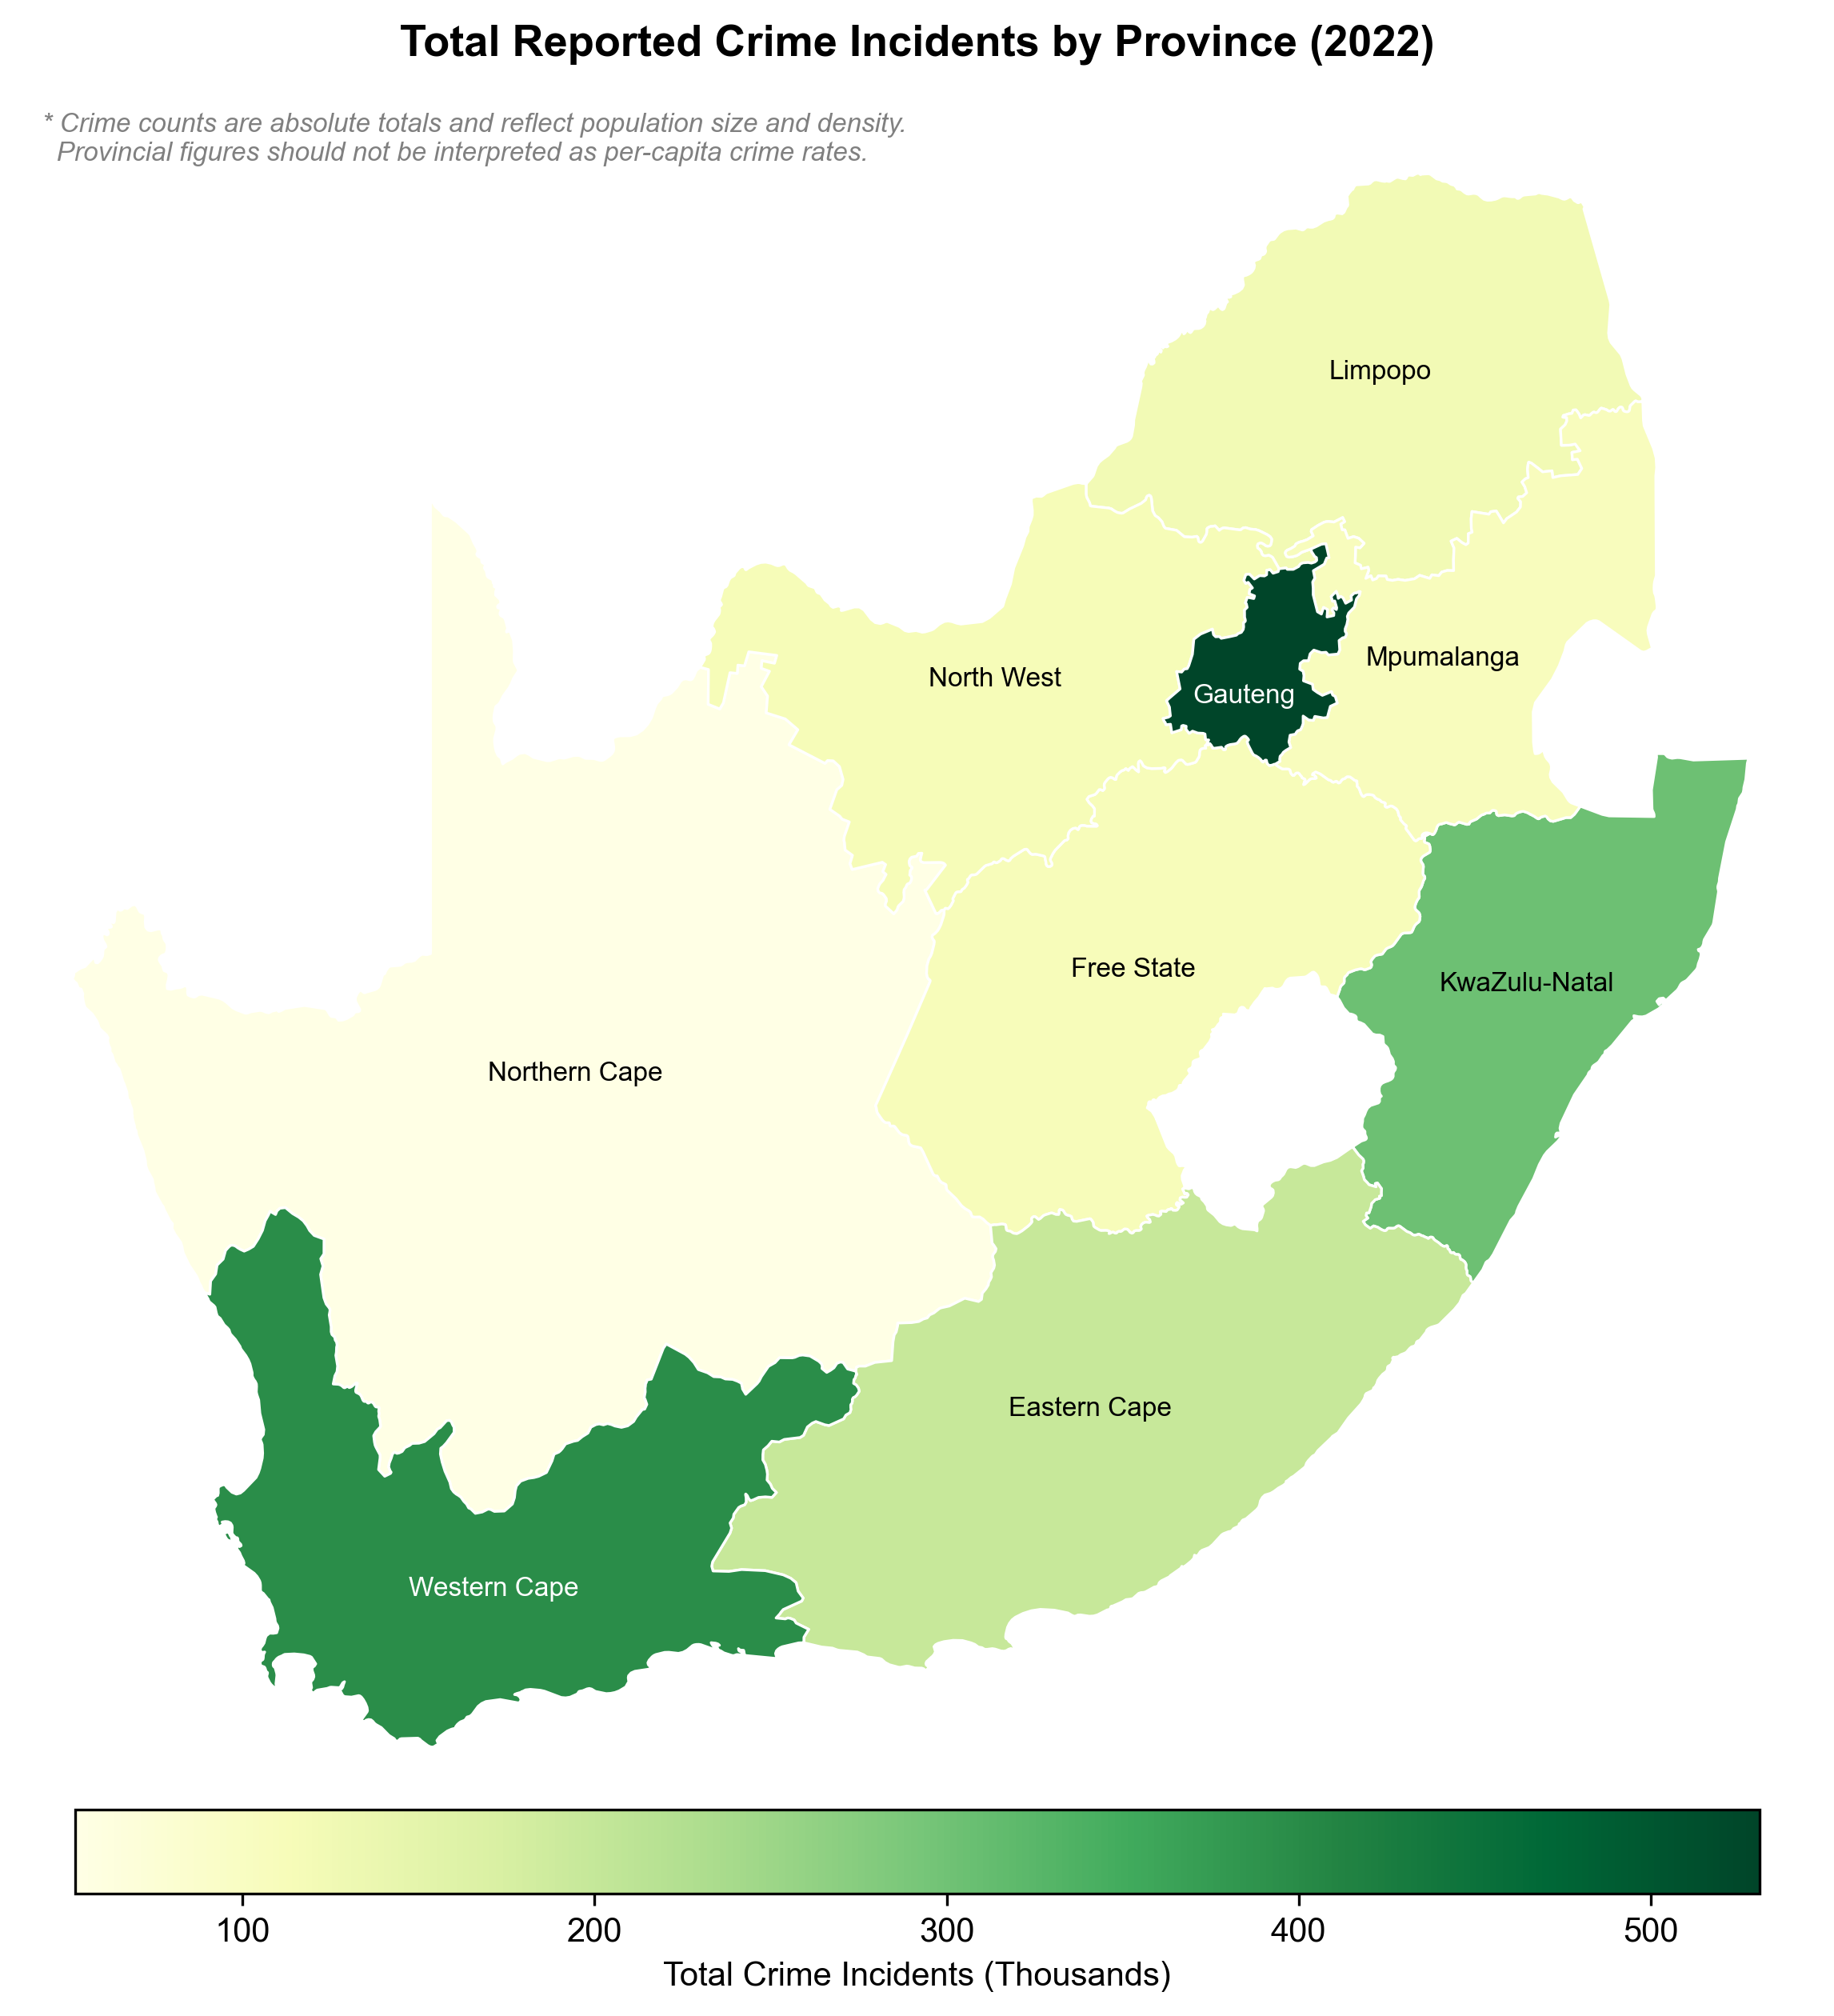

In [17]:
# Similar structure to choropleth map 1:

fig2, ax2 = plt.subplots(figsize = (12,9))

sa_map_2022.plot(column        = 'incident_count', 
                 cmap          = 'YlGn',                 
                 linewidth     =  0.8, 
                 edgecolor     = 'white',
                 legend        = True,
                 legend_kwds   = {'label'      : 'Total Crime Incidents (Thousands)',
                                  'orientation': 'horizontal',
                                  'shrink'     : 0.6,
                                  'pad'        : 0.02},
                 ax = ax2)

dark_provinces = ['Gauteng', 'Western Cape']

manual_positions = {'Gauteng'      : (27.95, -26.4),        
                    'Western Cape' : (20.60, -33.6),
                    'Mpumalanga'   : (29.90, -26.1)} 

for _, row in sa_map_2022.iterrows():                        
    label_colour = 'white' if row['province'] in dark_provinces else 'black'

    if row['province'] in manual_positions:
        cx, cy = manual_positions[row['province']]
    else:
        cx = row.geometry.centroid.x
        cy = row.geometry.centroid.y
    
    ax2.annotate(text       = row['province'],
                 xy         = (cx, cy),
                 ha         = 'center', 
                 fontsize   = 8, 
                 color      = label_colour)
                
ax2.set_title('Total Reported Crime Incidents by Province (2022)', fontsize = 13, fontweight = 'bold', pad = 12)
ax2.set_axis_off()

ax2.set_xlim([16, 33.5])
ax2.set_ylim([-35, -21.5])

ax2.text(x         = 0.01,
         y         = 0.99,
         s         = '* Crime counts are absolute totals and reflect population size and density.'
                     '\n  Provincial figures should not be interpreted as per-capita crime rates.',
         transform = ax2.transAxes,
         fontsize  = 8,
         va        = 'top',
         ha        = 'left',
         color     = 'grey',
         style     = 'italic')

colour_bar = ax2.get_figure().axes[-1]
colour_bar.set_xticklabels([f'{int(x/1e3)}' for x in colour_bar.get_xticks()])   

plt.tight_layout()
plt.savefig('reports/figures/choropleth_2022.png', dpi = 300, bbox_inches = 'tight')
plt.show()

The output of this notebook is as follows: two visualisations `choropleth_total.png` and `choropleth_2022.png`, both of which are saved to `reports/figures/` for the dashboarding and technical reporting stages in the project pipeline. 